In [67]:
import os
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pyarrow.parquet as pq
from matplotlib.colors import LogNorm

In [45]:
INPUT_ROOT = Path("/Users/hyeonghan/Downloads/Dec25-sims-mcoadd-mask-release")
SHEAR_TYPE = "noshear"
MOSAICS = [0, 1, 2, 3]

S2N_COLUMNS = ["snr", "gauss_s2n", "wmom_s2n", "pgauss_s2n"]
FLAG_COLUMN = "flagged"

T_COLUMN = "gauss_T"
TPSF_COLUMN = "gauss_Tpsf"


In [5]:
paths = [INPUT_ROOT / f"shear_type={SHEAR_TYPE}" / f"mosaic={mosaic}" / "part-0.parquet" for mosaic in MOSAICS]

In [50]:
for path in paths:
    table = pq.read_table(path, columns=S2N_COLUMNS + [FLAG_COLUMN] + [T_COLUMN] + [TPSF_COLUMN])
    flagged = table[FLAG_COLUMN].to_numpy(zero_copy_only=False).astype(bool)

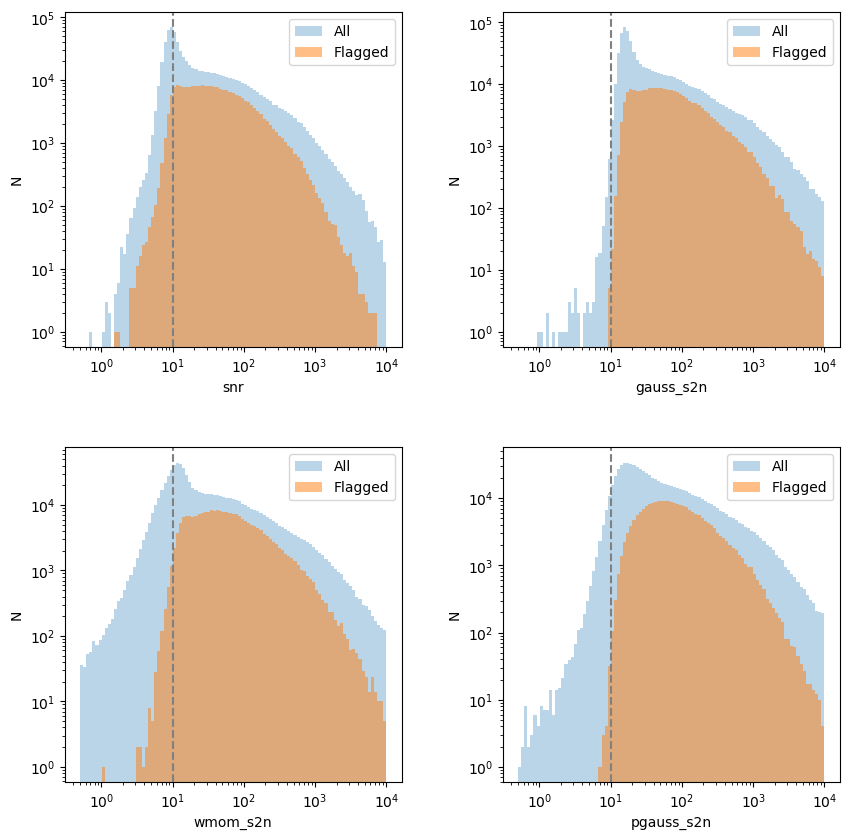

In [44]:
fig, axes = plt.subplots(2, 2, figsize=(10, 10))

bins = np.logspace(np.log10(0.5), np.log10(1e4), 100)

for cnt,ax in enumerate(axes.flat):
    ax.hist(table[S2N_COLUMNS[cnt]], bins=bins, alpha=0.3, label='All')
    ax.hist(table[S2N_COLUMNS[cnt]].to_numpy(zero_copy_only=False)[flagged], bins=bins, alpha=0.5, label='Flagged')

    ax.set_xscale('log')
    ax.set_yscale('log')
    
    ax.axvline(10, c='gray', ls='--')
    
    ax.set_xlabel(S2N_COLUMNS[cnt])
    ax.set_ylabel('N')
    ax.legend()


fig.subplots_adjust(wspace=0.30, hspace=0.30)

plt.show()

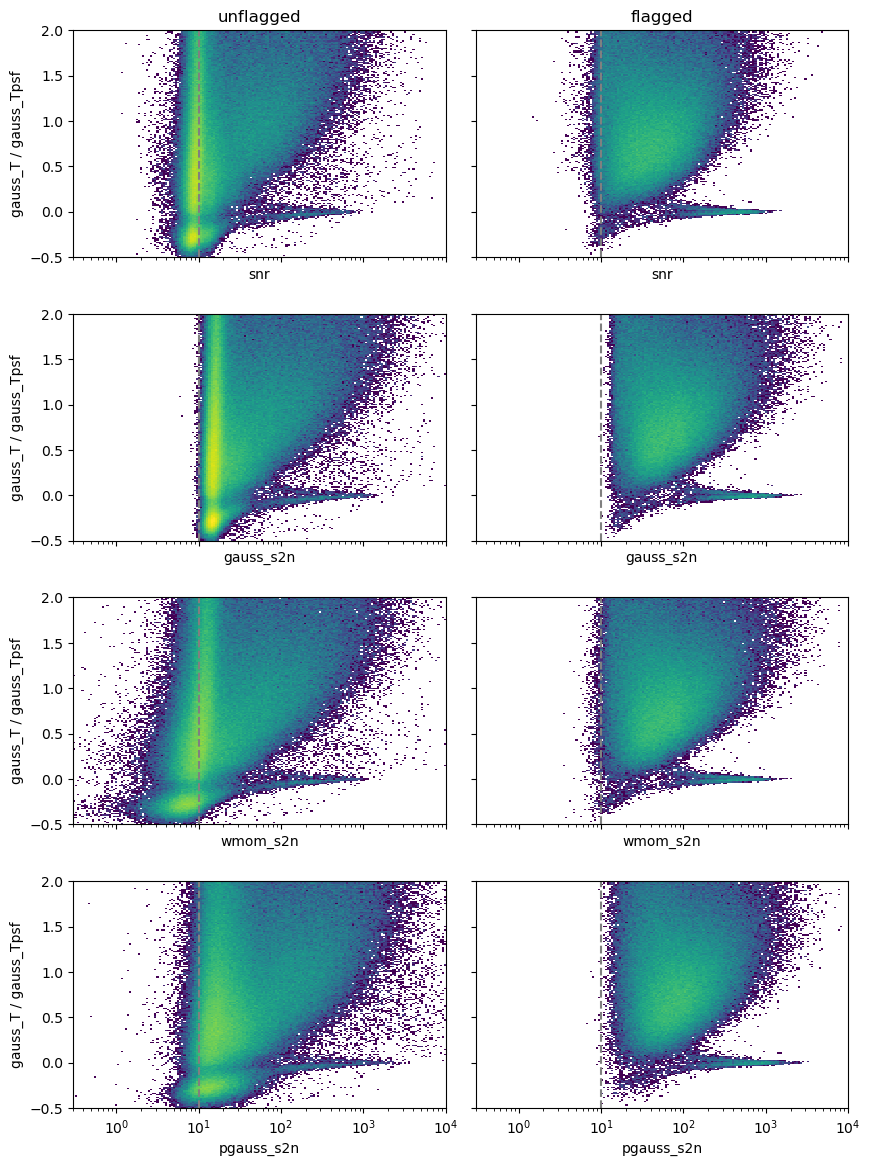

In [72]:

gauss_T = table["gauss_T"].to_numpy(zero_copy_only=False)
gauss_Tpsf = table["gauss_Tpsf"].to_numpy(zero_copy_only=False)
T_ratio = gauss_T / gauss_Tpsf

unflagged = ~flagged

xbins = np.logspace(np.log10(0.3), np.log10(1e4), 180)
ybins = np.linspace(-0.5, 2.0, 180)

histograms = []
global_max = 0

for col in S2N_COLUMNS:
    s2n = table[col].to_numpy(zero_copy_only=False)

    base_mask = (
        np.isfinite(s2n) &
        np.isfinite(T_ratio) &
        (s2n > 0)
    )

    for sample_mask in [unflagged, flagged]:
        mask = base_mask & sample_mask

        H, xedges, yedges = np.histogram2d(s2n[mask], T_ratio[mask], bins=[xbins, ybins])

        histograms.append((col, H, xedges, yedges))
        if H.max() > global_max:
            global_max = H.max()

# figure
fig, axes = plt.subplots(nrows=len(S2N_COLUMNS), ncols=2, figsize=(10, 14), sharex=True, sharey=True)


norm = LogNorm(vmin=1, vmax=global_max)


k = 0
for i, col in enumerate(S2N_COLUMNS):
    for j, label in enumerate(["unflagged", "flagged"]):
        ax = axes[i, j]

        _, H, xedges, yedges = histograms[k]
        k += 1

        H = np.ma.masked_where(H == 0, H)

        im = ax.pcolormesh(xedges, yedges, H.T, shading="auto", norm=norm)

        ax.set_xscale("log")
        ax.axvline(10, c="gray", ls="--")

        if i == 0:
            ax.set_title(label)

        ax.set_xlabel(col)
        
        if j == 0:
            ax.set_ylabel("gauss_T / gauss_Tpsf")

cbar.set_label("count per bin")

fig.subplots_adjust(wspace=0.08, hspace=0.25)

plt.show()